# Chapter 9 — Bayesian Linear Regression, Priors, and Regularisation

This notebook accompanies **Chapter 9** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

Chapter 7 treated the regression coefficients as fixed unknowns estimated by maximum likelihood.  Chapter 9 promotes them to **latent random variables** and places prior distributions on them.  Two things follow:

1. **Posterior uncertainty**: instead of a single best-fit line, we get a distribution over plausible lines.  More data → tighter posterior → less uncertainty.
2. **Shrinkage / regularisation**: if we use a prior that concentrates near zero, the posterior mode (MAP estimate) penalises large coefficients.  Gaussian prior → **ridge regression**; Laplace prior → **lasso regression** (which drives some coefficients to exactly zero).

We continue using the body fat dataset and standardised predictors throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invgamma
from scipy.optimize import minimize

rng = np.random.default_rng(42)

---
## Data preparation

We **standardise** each predictor to zero mean and unit variance so that coefficient magnitudes are comparable across predictors and the shrinkage prior treats them fairly.

> **Book link — §9.2.**  Standardised predictors allow us to compare coefficient magnitudes directly: a coefficient $\beta_k^*$ tells us how much body fat changes per standard deviation of predictor $k$.

In [2]:
df = pd.read_csv('../DATA/bodyFatClean.csv')
predictors = [c for c in df.columns if c != 'BodyFat']
y = df['BodyFat'].values
n_full = len(y)

# Standardise predictors (zero mean, unit std)
pred_mean = df[predictors].values.mean(axis=0)
pred_std  = df[predictors].values.std(axis=0, ddof=1)
Z = (df[predictors].values - pred_mean) / pred_std   # n × 13 standardised matrix

def design(Z_rows):
    """Add intercept column to a matrix of standardised predictors."""
    return np.column_stack([np.ones(len(Z_rows)), Z_rows])

print(f"Dataset: {n_full} observations, {len(predictors)} standardised predictors")

Dataset: 248 observations, 14 standardised predictors


---
## Posterior sampling

Under flat priors on $\boldsymbol{B}$ and $\log\Sigma$, the posterior has a clean closed form (§9.1.3).  To draw a sample $(\boldsymbol{\beta}, \sigma)$ from the posterior we:

1. Sample $\sigma^2 \sim \mathrm{Inv\text{-}Gamma}\!\left(\tfrac{\nu}{2},\, \tfrac{\nu s^2}{2}\right)$ where $\nu = n - p - 1$ and $s^2 = \mathrm{RSS}/\nu$.
2. Sample $\boldsymbol{B} \mid \sigma \sim \mathcal{N}\!\left(\hat{\boldsymbol{\beta}},\, \sigma^2 (\mathbf{X}^\top \mathbf{X})^{-1}\right)$.

Each sample is a complete plausible model consistent with the data.

> **Book link — §9.1.3, eqs. 9.18–9.21.**

In [3]:
def sample_posterior(X_des, y_vec, n_samples=50):
    """Draw posterior samples (beta, sigma) under flat priors."""
    n, p = X_des.shape
    XtX      = X_des.T @ X_des
    beta_hat = np.linalg.solve(XtX, X_des.T @ y_vec)
    resid    = y_vec - X_des @ beta_hat
    nu       = n - p                        # degrees of freedom
    s2       = (resid @ resid) / nu         # unbiased variance estimate
    XtX_inv  = np.linalg.inv(XtX)

    # Step 1: sample sigma^2
    sigma2_samp = invgamma.rvs(a=nu/2, scale=nu*s2/2, size=n_samples,
                               random_state=rng.integers(1e9))
    # Step 2: sample beta | sigma
    beta_samp = np.array([
        rng.multivariate_normal(beta_hat, s2i * XtX_inv)
        for s2i in sigma2_samp
    ])
    return beta_samp, np.sqrt(sigma2_samp), beta_hat, np.sqrt(s2)

Now let's reproduce Figure 9.1 from the book: fifty sampled regression lines for a **small** ($n=20$) and **large** ($n=200$) subset of the data, using only standardised abdomen as the predictor.

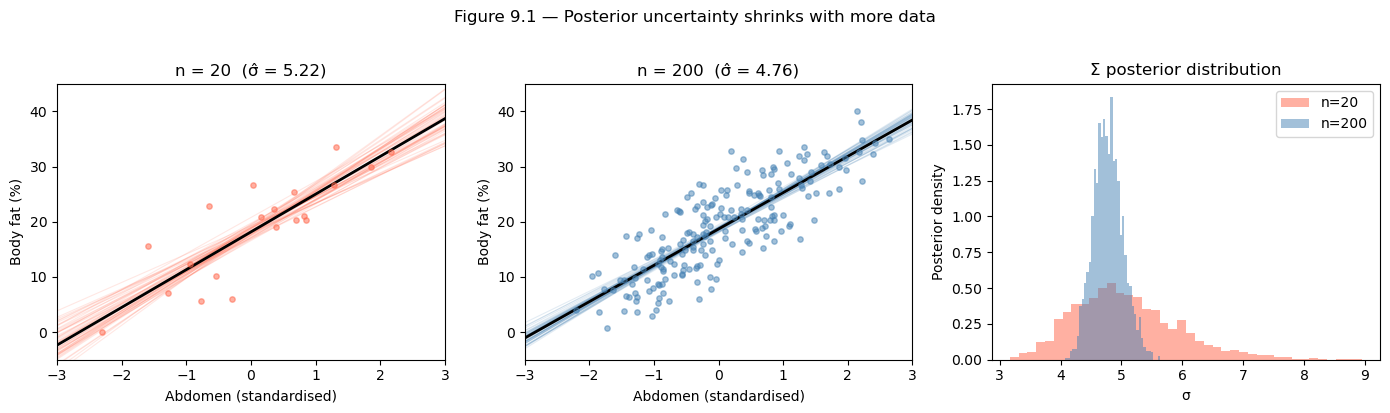

In [4]:
z_abd   = Z[:, predictors.index('Abdomen')]   # standardised abdomen
x_grid  = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors    = ['tomato', 'steelblue']

for ax, n_sub, col in zip(axes[:2], [20, 200], colors):
    idx   = rng.choice(n_full, n_sub, replace=False)
    z_s   = z_abd[idx]
    y_s   = y[idx]
    X_s   = design(z_s.reshape(-1, 1))
    betas, sigmas, b_hat, s_hat = sample_posterior(X_s, y_s)

    for b in betas:
        ax.plot(x_grid, b[0] + b[1]*x_grid, color=col, alpha=0.15, lw=0.8)
    ax.scatter(z_s, y_s, s=15, color=col, alpha=0.5, zorder=3)
    ax.plot(x_grid, b_hat[0] + b_hat[1]*x_grid, 'k', lw=2)
    ax.set_xlabel('Abdomen (standardised)')
    ax.set_ylabel('Body fat (%)')
    ax.set_title(f'n = {n_sub}  (σ̂ = {s_hat:.2f})')
    ax.set_xlim(-3, 3); ax.set_ylim(-5, 45)

# Right panel: sigma posteriors for both n values
ax = axes[2]
for n_sub, col, label in zip([20, 200], colors, ['n=20', 'n=200']):
    idx   = rng.choice(n_full, n_sub, replace=False)
    X_s   = design(z_abd[idx].reshape(-1, 1))
    _, sigmas, _, _ = sample_posterior(X_s, y[idx], n_samples=2000)
    ax.hist(sigmas, bins=40, alpha=0.5, color=col, label=label, density=True)
ax.set_xlabel('σ'); ax.set_ylabel('Posterior density')
ax.set_title('Σ posterior distribution')
ax.legend()

plt.suptitle('Figure 9.1 — Posterior uncertainty shrinks with more data', y=1.02)
plt.tight_layout()
plt.show()

With only 20 observations the posterior spans a wide family of plausible lines — the model is uncertain about both the slope and the noise level.  By $n = 200$ the lines have converged to a narrow band and the $\sigma$ posterior is sharply peaked.

---
## Ridge regression

When we place a Gaussian prior $B_k \sim \mathcal{N}(0, \sigma^2/\lambda)$ on each predictor coefficient, the MAP estimate solves:

$$\hat{\boldsymbol{\beta}} = \operatorname{arg\,min}_{\boldsymbol{\beta}} \left[ \sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_{k=1}^p \beta_k^2 \right].$$

This has the closed-form solution $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I}_\epsilon)^{-1} \mathbf{X}^\top \mathbf{y}$ where $\mathbf{I}_\epsilon$ is the identity matrix with a zero in the intercept position (we don't penalise $\beta_0$).

> **Book link — §9.3, eq. 9.26.**  As $\lambda \to 0$ we recover OLS.  As $\lambda \to \infty$ all coefficients shrink to zero.

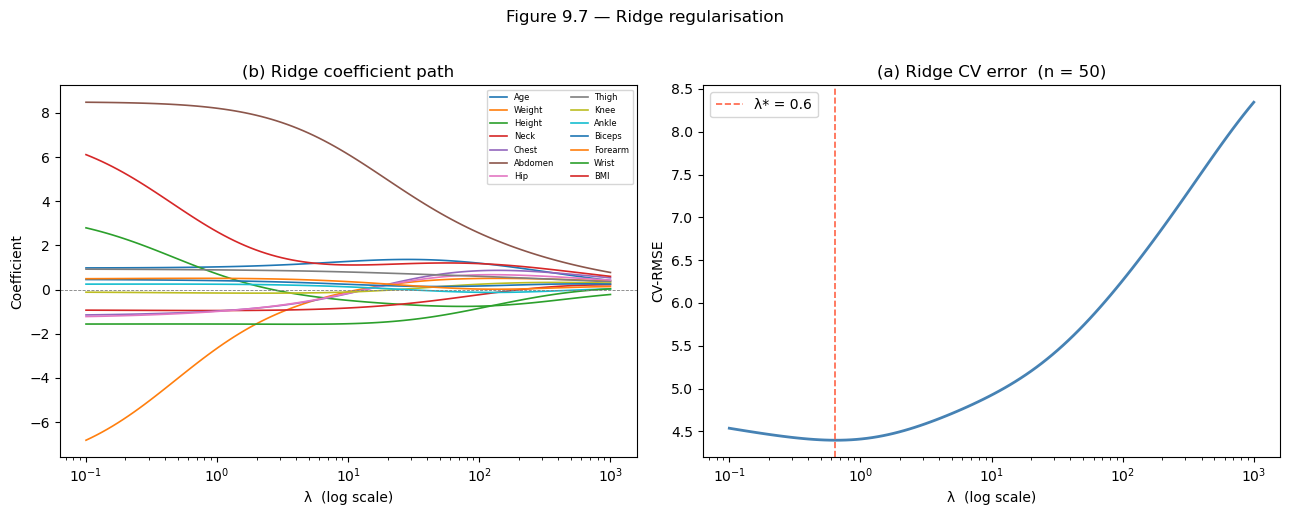

Optimal λ = 0.64
CV-RMSE at λ* = 4.397


In [5]:
def ridge_fit(Z_mat, y_vec, lam):
    """Ridge MAP: (X'X + lam*I_eps)^{-1} X'y.  No penalty on intercept."""
    X = design(Z_mat)
    p = X.shape[1]
    pen = lam * np.eye(p)
    pen[0, 0] = 0                        # leave intercept unpenalised
    return np.linalg.solve(X.T @ X + pen, X.T @ y_vec)

# Regularisation path on the full dataset
lambdas  = np.logspace(-1, 3, 100)
ridge_path = np.array([ridge_fit(Z, y, lam)[1:] for lam in lambdas])  # exclude intercept

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for k, name in enumerate(predictors):
    ax.plot(lambdas, ridge_path[:, k], lw=1.2, label=name)
ax.set_xscale('log')
ax.axhline(0, color='grey', lw=0.6, linestyle='--')
ax.set_xlabel('λ  (log scale)')
ax.set_ylabel('Coefficient')
ax.set_title('(b) Ridge coefficient path')
ax.legend(fontsize=6, ncol=2, loc='upper right')

# Cross-validated RMSE on a small subsample (to exaggerate overfitting, as in book)
rng2  = np.random.default_rng(7)
idx50 = rng2.choice(n_full, 50, replace=False)
Z50, y50 = Z[idx50], y[idx50]
n_fold = 5
fold_ids = np.array_split(rng2.permutation(50), n_fold)

cv_rmse = []
for lam in lambdas:
    errs = []
    for fold in fold_ids:
        train = np.setdiff1d(np.arange(50), fold)
        beta  = ridge_fit(Z50[train], y50[train], lam)
        yhat  = design(Z50[fold]) @ beta
        errs.append(np.mean((y50[fold] - yhat)**2))
    cv_rmse.append(np.sqrt(np.mean(errs)))

cv_rmse = np.array(cv_rmse)
lam_opt = lambdas[np.argmin(cv_rmse)]

ax = axes[1]
ax.plot(lambdas, cv_rmse, 'steelblue', lw=2)
ax.axvline(lam_opt, color='tomato', linestyle='--', lw=1.2,
           label=f'λ* = {lam_opt:.1f}')
ax.set_xscale('log')
ax.set_xlabel('λ  (log scale)')
ax.set_ylabel('CV-RMSE')
ax.set_title(f'(a) Ridge CV error  (n = 50)')
ax.legend()

plt.suptitle('Figure 9.7 — Ridge regularisation', y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal λ = {lam_opt:.2f}")
print(f"CV-RMSE at λ* = {cv_rmse.min():.3f}")

As $\lambda$ increases all coefficients shrink toward zero (but none reach exactly zero), and the CV error follows the characteristic **U-shape**: too small → overfitting; too large → underfitting.

---
## Lasso regression

Replacing the Gaussian prior with a **Laplace** prior $f(\beta_k) \propto \exp(-\lambda|\beta_k|/2\sigma^2)$ gives the lasso MAP problem:

$$\hat{\boldsymbol{\beta}} = \operatorname{arg\,min}_{\boldsymbol{\beta}} \left[ \sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_{k=1}^p |\beta_k| \right].$$

The $\ell_1$ penalty has sharp corners at zero, which forces some coefficients to become **exactly zero** — automatic variable selection.

> **Book link — §9.4, eq. 9.28.**  Ridge shrinks everyone; lasso eliminates some predictors entirely.

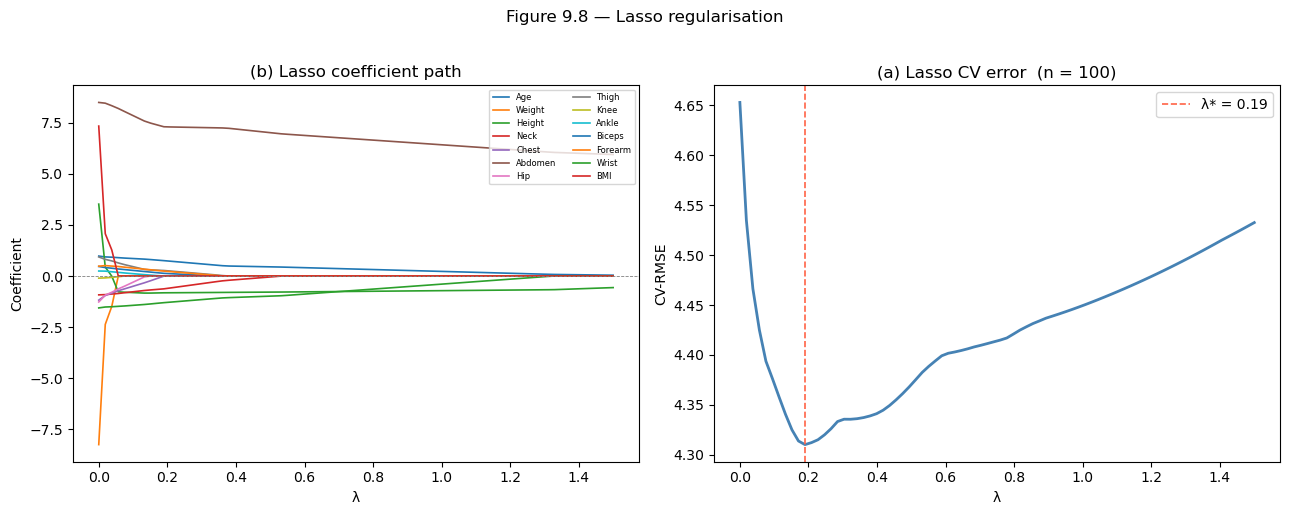

Optimal λ = 0.19
Non-zero predictors (9/14): ['Age', 'Height', 'Neck', 'Chest', 'Abdomen', 'Thigh', 'Biceps', 'Forearm', 'Wrist']


In [6]:
def lasso_fit(Z_mat, y_vec, lam):
    """Lasso via coordinate descent.  No penalty on intercept."""
    X = design(Z_mat)
    n, p = X.shape
    beta = np.zeros(p)
    beta[0] = y_vec.mean()

    for _ in range(2000):
        beta_old = beta.copy()
        for k in range(p):
            r_k = y_vec - X @ beta + X[:, k] * beta[k]   # partial residual
            c_k = X[:, k] @ r_k / n
            a_k = X[:, k] @ X[:, k] / n
            if k == 0:                                     # intercept: no penalty
                beta[k] = c_k / a_k
            else:
                beta[k] = np.sign(c_k) * max(abs(c_k) - lam/2, 0) / a_k
        if np.max(np.abs(beta - beta_old)) < 1e-7:
            break
    return beta

# Lasso path
lasso_lambdas = np.linspace(0, 1.5, 80)
lasso_path = np.array([lasso_fit(Z, y, lam)[1:] for lam in lasso_lambdas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for k, name in enumerate(predictors):
    ax.plot(lasso_lambdas, lasso_path[:, k], lw=1.2, label=name)
ax.axhline(0, color='grey', lw=0.6, linestyle='--')
ax.set_xlabel('λ')
ax.set_ylabel('Coefficient')
ax.set_title('(b) Lasso coefficient path')
ax.legend(fontsize=6, ncol=2, loc='upper right')

# Lasso CV on n=100 subsample
idx100 = rng2.choice(n_full, 100, replace=False)
Z100, y100 = Z[idx100], y[idx100]
fold_ids100 = np.array_split(rng2.permutation(100), n_fold)

cv_rmse_lasso = []
for lam in lasso_lambdas:
    errs = []
    for fold in fold_ids100:
        train = np.setdiff1d(np.arange(100), fold)
        beta  = lasso_fit(Z100[train], y100[train], lam)
        yhat  = design(Z100[fold]) @ beta
        errs.append(np.mean((y100[fold] - yhat)**2))
    cv_rmse_lasso.append(np.sqrt(np.mean(errs)))

cv_rmse_lasso = np.array(cv_rmse_lasso)
lam_opt_lasso = lasso_lambdas[np.argmin(cv_rmse_lasso)]

ax = axes[1]
ax.plot(lasso_lambdas, cv_rmse_lasso, 'steelblue', lw=2)
ax.axvline(lam_opt_lasso, color='tomato', linestyle='--', lw=1.2,
           label=f'λ* = {lam_opt_lasso:.2f}')
ax.set_xlabel('λ')
ax.set_ylabel('CV-RMSE')
ax.set_title('(a) Lasso CV error  (n = 100)')
ax.legend()

plt.suptitle('Figure 9.8 — Lasso regularisation', y=1.02)
plt.tight_layout()
plt.show()

# How many coefficients are nonzero at the optimal lambda?
beta_opt = lasso_fit(Z, y, lam_opt_lasso)
nonzero  = [predictors[k] for k in range(len(predictors)) if abs(beta_opt[k+1]) > 1e-4]
print(f"Optimal λ = {lam_opt_lasso:.2f}")
print(f"Non-zero predictors ({len(nonzero)}/{len(predictors)}): {nonzero}")

Unlike ridge, the lasso path has coefficients that **hit zero** at a finite $\lambda$ and stay there — the model selects a sparse subset of predictors automatically.

---
## Exercises

### Exercise 1 — Ridge recovers OLS at λ = 0

Verify numerically that the ridge estimate with $\lambda = 0$ gives the same coefficients as ordinary least squares on the standardised predictors.  Compute both and print the maximum absolute difference.

In [7]:
# Your answer here

In [8]:
# Solution
X_full  = design(Z)
beta_ols   = np.linalg.solve(X_full.T @ X_full, X_full.T @ y)
beta_ridge0 = ridge_fit(Z, y, lam=0)

print("Max |ridge(λ=0) − OLS| =", np.max(np.abs(beta_ridge0 - beta_ols)))
# Should be machine-precision small

Max |ridge(λ=0) − OLS| = 0.0


### Exercise 2 — Sigma posterior: small vs large data

Using all 13 standardised predictors (not just abdomen), draw 2000 posterior samples of $\sigma$ for two subsets of the data: $n=30$ and all $n=248$ observations.  Plot the two histograms overlaid.  At which sample size is the posterior already quite narrow?

In [9]:
# Your answer here

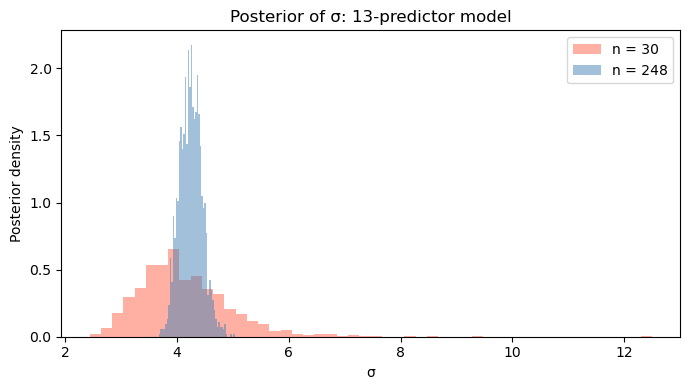

In [10]:
# Solution
fig, ax = plt.subplots(figsize=(7, 4))

for n_sub, col, label in [(30, 'tomato', 'n = 30'), (248, 'steelblue', 'n = 248')]:
    idx  = rng.choice(n_full, n_sub, replace=False)
    X_s  = design(Z[idx])
    _, sigmas, _, _ = sample_posterior(X_s, y[idx], n_samples=2000)
    ax.hist(sigmas, bins=50, density=True, alpha=0.5, color=col, label=label)

ax.set_xlabel('σ')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior of σ: 13-predictor model')
ax.legend()
plt.tight_layout()
plt.show()

# With n=248 the posterior is quite tight — uncertainty about sigma is small.
# With n=30 the posterior is broad, reflecting that 30 points barely constrain 14 parameters.

### Exercise 3 — Ridge vs lasso: sparsity comparison

For the full dataset, compute ridge and lasso coefficients at a moderate penalty $\lambda = 0.3$.  Plot both sets of standardised coefficients as a horizontal bar chart side by side.  Which predictors does lasso set to zero that ridge keeps nonzero?

In [11]:
# Your answer here

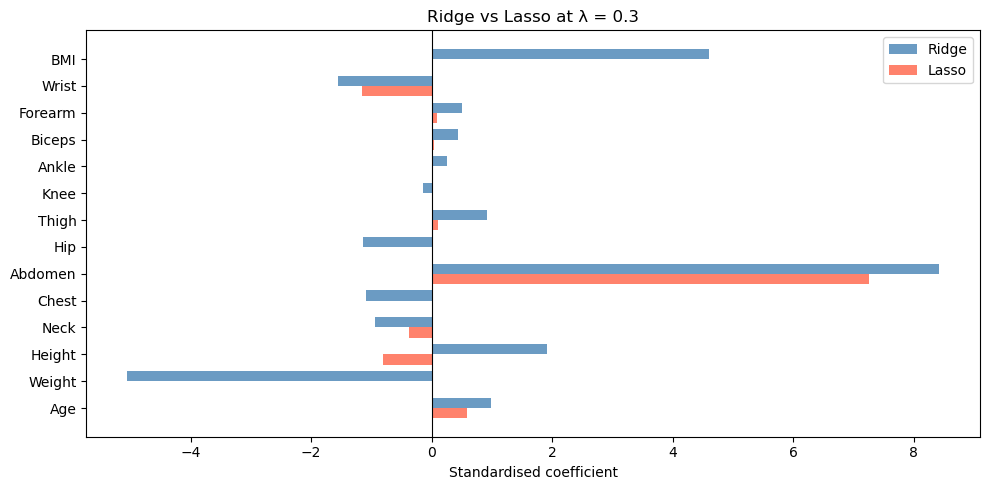

Lasso zeros at λ=0.3: ['Weight', 'Chest', 'Hip', 'Knee', 'Ankle', 'BMI']
Ridge keeps all predictors nonzero (smaller magnitude, but none exactly zero).


In [12]:
# Solution
lam_compare = 0.3
b_ridge = ridge_fit(Z, y, lam_compare)[1:]   # drop intercept
b_lasso = lasso_fit(Z, y, lam_compare)[1:]

x_pos   = np.arange(len(predictors))
width   = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(x_pos + width/2, b_ridge, width, color='steelblue', alpha=0.8, label='Ridge')
ax.barh(x_pos - width/2, b_lasso, width, color='tomato',    alpha=0.8, label='Lasso')
ax.set_yticks(x_pos)
ax.set_yticklabels(predictors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised coefficient')
ax.set_title(f'Ridge vs Lasso at λ = {lam_compare}')
ax.legend()
plt.tight_layout()
plt.show()

zero_lasso = [predictors[k] for k in range(len(predictors)) if abs(b_lasso[k]) < 1e-4]
print(f"Lasso zeros at λ={lam_compare}: {zero_lasso}")
print("Ridge keeps all predictors nonzero (smaller magnitude, but none exactly zero).")